In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.load('condensed_data.npy', allow_pickle=True).tolist()

In [3]:
nwindow = 1000
window = np.ones((nwindow,)) / nwindow

experiments = list(data.keys())
print(experiments)
nexp = len(experiments)

methods = ['sp','surrogate', 'standard']
opts = ['sgd','kfac']

name_map = {
    "standard": "standard",
    "sp": "sp",
    "surrogate": "sp+surr",
    "ibp": "ibp"
}

['surrogate_sgd', 'ibp_sgd', 'standard_kfac', 'ibp_kfac', 'surrogate_kfac', 'sp_kfac', 'standard_sgd', 'sp_sgd']


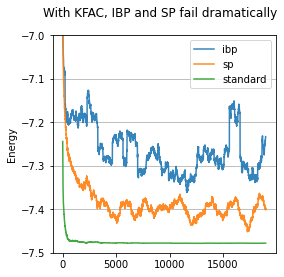

In [9]:
fig, ax = plt.subplots(figsize = (4,4))

fig.suptitle("With KFAC, IBP and SP fail dramatically")

ax.grid(axis='y')
ax.set_ylabel("Energy")
ax.set_ylim([-7.5, -7.0])

methods = ['ibp', 'sp', 'standard']
opt = 'kfac'
j=0

for m in methods:
    exp = f"{m}_{opt}"

    energies = data[exp][j]['energy_noclip']
    energies_smoothed = np.convolve(energies, window, 'valid')
    ax.plot(energies_smoothed, label=name_map[m], alpha=0.9)
    ax.legend()


Energies for ibp_kfac: [-7.26412129208979, -4.219189729269116, -7.381375078339457]
Energies for sp_kfac: [-7.402605929580092, -7.383444292181133, -7.398207601488531]
Energies for surrogate_kfac: [-7.471565884724021, -7.4721101891437165, -7.472680754182041]
Energies for standard_kfac: [-7.478045016235352, -7.4780276376123425, -7.478066590200425]


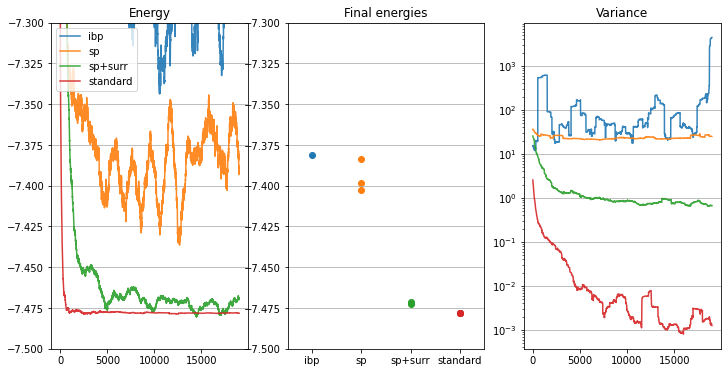

In [5]:
fig, axs = plt.subplots(ncols=3, figsize = (12,6))

# fig.suptitle("Using a surrogate yields much better energies and reduces the variance")

ax = axs[0]
ax.grid(axis='y')
ax.set_title("Energy")
ax.set_ylim(-7.5, -7.3)

ax = axs[2]
ax.grid(axis='y')
ax.set_title("Variance")
ax.set_yscale('log')

methods = ['ibp','sp', 'surrogate', 'standard']
opt = 'kfac'
j=1

for m in methods:
    exp = f"{m}_{opt}"

    ax = axs[0]
    energies = data[exp][j]['energy_noclip']
    energies_smoothed = np.convolve(energies, window, 'valid')
    ax.plot(energies_smoothed, label=name_map[m], alpha=0.9)
    ax.legend()
       
    ax = axs[2]
    variances = data[exp][j]['variance_noclip']
    variances_smoothed = np.convolve(variances, window, 'valid')
    ax.plot(variances_smoothed, label=name_map[m], alpha=0.9)

ax = axs[1]
ax.grid(axis='y')
ax.set_title("Final energies")
ax.set_xlim([-0.5,3.5])
ax.set_ylim([-7.5, -7.3])

for m in methods:
    exp = f"{m}_{opt}"
    energies = []
    nexp = 3

    for j in range(nexp):
        energies.append(data[exp][j]['eval_stats']['average'])

    print(f"Energies for {exp}: {energies}")

    ax.scatter(nexp*(f"{name_map[m]}",), energies)



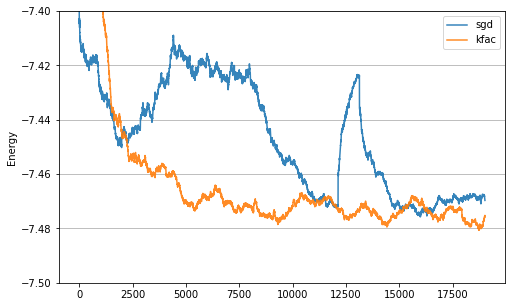

In [6]:
fig, ax = plt.subplots(figsize = (8,5))

# fig.suptitle("In fact, KFAC is the preferred optimizer for SP+surrogate method")

ax.grid(axis='y')
ax.set_ylabel("Energy")
ax.set_ylim([-7.5,-7.4])

opt = 'kfac'
j=0
m = 'surrogate'

for opt in ['sgd','kfac']:
    exp = f"{m}_{opt}"

    energies = data[exp][j]['energy_noclip']
    energies_smoothed = np.convolve(energies, window, 'valid')
    ax.plot(energies_smoothed, label=opt, alpha=0.9)
    ax.legend()

Energies for ibp_sgd: [-7.466798380760431, -7.45796886021459, -7.454608709173322]
Energies for sp_sgd: [-7.435029413363695, -7.451493687648952, -7.465742796894908]
Energies for surrogate_sgd: [-7.468711769039213, -7.473600046380877, -7.4681751806275845]
Energies for standard_sgd: [-7.477046774331927, -7.476140399780332, -7.477278931236148]


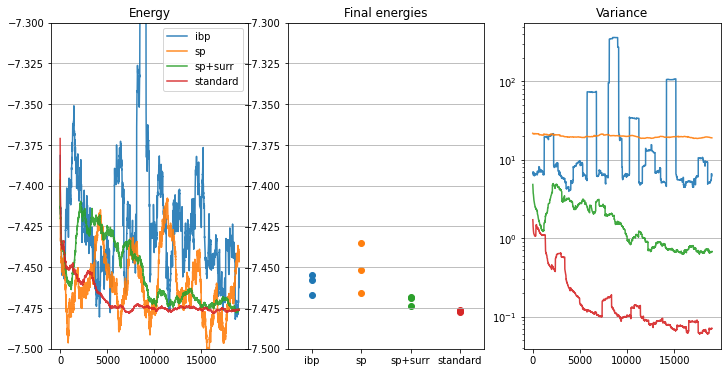

In [7]:
fig, axs = plt.subplots(ncols=3, figsize = (12,6))

# fig.suptitle("Even with SGD, SP+surrogate beats IBP and SP in both energies and variance")

ax = axs[0]
ax.grid(axis='y')
ax.set_title("Energy")
ax.set_ylim(-7.5, -7.3)

ax = axs[2]
ax.grid(axis='y')
ax.set_title("Variance")
ax.set_yscale('log')

methods = ['ibp','sp', 'surrogate', 'standard']
opt = 'sgd'
j=1

for m in methods:
    exp = f"{m}_{opt}"

    ax = axs[0]
    energies = data[exp][j]['energy_noclip']
    energies_smoothed = np.convolve(energies, window, 'valid')
    ax.plot(energies_smoothed, label=name_map[m], alpha=0.9)
    ax.legend()
       
    ax = axs[2]
    variances = data[exp][j]['variance_noclip']
    variances_smoothed = np.convolve(variances, window, 'valid')
    ax.plot(variances_smoothed, label=name_map[m], alpha=0.9)

ax = axs[1]
ax.grid(axis='y')
ax.set_title("Final energies")
ax.set_xlim([-0.5,3.5])
ax.set_ylim([-7.5, -7.3])

for m in methods:
    exp = f"{m}_{opt}"
    energies = []
    nexp = 3

    for j in range(nexp):
        energies.append(data[exp][j]['eval_stats']['average'])

    print(f"Energies for {exp}: {energies}")

    ax.scatter(nexp*(f"{name_map[m]}",), energies)
    



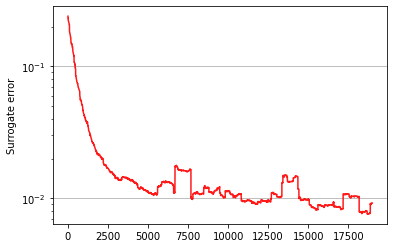

In [8]:
fig, ax = plt.subplots()
nchains = 100

# ax.set_title("Mean squared error of surrogate over training process")
ax.set_yscale('log')
ax.grid(axis='y')
ax.set_ylabel("Surrogate error")

m = 'surrogate'
opt='kfac'

exp = f"{m}_{opt}"
sg_error = data[exp][j]['sg_error'] / nchains
sg_error_smoothed = np.convolve(sg_error, window, 'valid')
ax.plot(sg_error_smoothed, alpha=0.9, color='r')